In [1]:
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf
import torch

from case_studies.sdss_galaxies_vae.reconstruction import load_models, reconstruct_scene_at_coordinates

In [2]:
import os
os.environ["BLISS_HOME"] = "/home/dereklh/projects/bliss/"

In [3]:
with initialize(config_path="../sdss_galaxies_vae/config", job_name="overlap"):
    cfg = compose(config_name="config", overrides=["models.prior.mean_sources=0.4"])   
    #print(OmegaConf.to_yaml(cfg))

simulated_dataset = instantiate(cfg.datasets.simulated)

In [4]:
simulated_dataset = instantiate(cfg.datasets.simulated)

In [5]:
batch_size=1
n_tiles_h=5
n_tiles_w=5
#tile_catalog = simulated_dataset.sample_prior(batch_size, n_tiles_h, n_tiles_w)
#torch.save(tile_catalog, "catalog.pt")
tile_catalog = torch.load("catalog.pt")

In [6]:
img, bg = simulated_dataset.simulate_image_from_catalog(tile_catalog)

In [7]:
import matplotlib.pyplot as plt

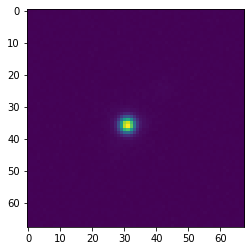

In [8]:
%matplotlib inline
plt.imshow(img[0, 0])

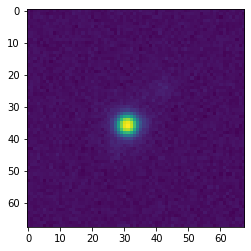

In [9]:

plt.imshow(img[0, 0].log())

In [10]:
tile_catalog["galaxy_params"].shape

torch.Size([1, 5, 5, 1, 7])

In [11]:
# load bliss
device = torch.device(cfg.reconstruct.device)
decoder, encoder, _ = load_models(cfg, device)
bp = 24
h, w = img.shape[2], img.shape[3]
# img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h-bp), (bp, w-bp))
img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 62.76it/s]


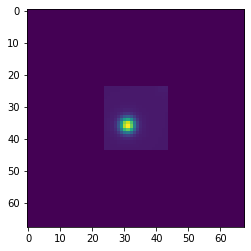

In [12]:
plt.imshow(torch.nn.functional.pad(img_recon[0, 0], (bp, bp, bp, bp)))

In [13]:
tile_map_recon.n_sources

tensor([[[0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 0, 0, 0]]], device='cuda:0')

In [14]:
tile_catalog.n_sources

tensor([[[0, 0, 1, 1, 1],
         [1, 0, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 1, 1, 0, 0],
         [1, 0, 0, 1, 0]]])

In [15]:
tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[1.1704e-02, 1.4448e-03, 3.4310e-04, 7.1347e-04, 8.9247e-01],
        [6.8183e-03, 4.1694e-03, 2.0601e-03, 9.5222e-04, 2.4314e-03],
        [4.2886e-03, 6.4177e-02, 1.4889e-02, 3.2840e-03, 4.0619e-04],
        [8.3669e-04, 9.7658e-01, 9.9904e-04, 2.0666e-02, 1.8588e-04],
        [1.4539e-03, 3.5424e-03, 2.7074e-02, 2.5458e-03, 6.0154e-04]],
       device='cuda:0')

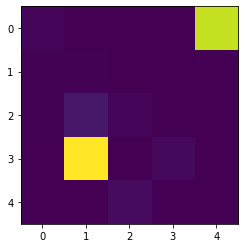

In [16]:
plt.imshow(tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

In [17]:
tile_map_recon.locs[0, 3, 1, 0]

tensor([0.0510, 0.8286], device='cuda:0')

In [18]:
tile_catalog.locs[0, 3, 1, 0]

tensor([0.0322, 0.8106])

In [19]:
tile_catalog2 = tile_catalog.copy()
tile_catalog2.locs = tile_catalog.locs.clone()
tile_catalog2.locs[0, 3, 1, 0] = 0.999

In [45]:
img2, bg2 = simulated_dataset.simulate_image_from_catalog(tile_catalog2)

In [46]:
img_recon2, tile_map_recon2 = reconstruct_scene_at_coordinates(encoder, decoder, img2, bg2, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 62.16it/s]


In [47]:
tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[8.2553e-05, 7.3370e-05, 1.8702e-04, 6.8412e-03, 9.5155e-01],
        [2.9000e-02, 5.4188e-03, 4.0239e-04, 1.0594e-03, 9.5907e-04],
        [4.0387e-03, 5.1599e-03, 4.1764e-03, 2.8708e-03, 1.0101e-03],
        [3.1408e-03, 1.0793e-01, 1.7730e-01, 7.1006e-03, 1.1354e-04],
        [9.8721e-04, 1.5845e-01, 9.6621e-02, 6.6377e-03, 7.1828e-05]],
       device='cuda:0')

In [23]:
tile_map_recon2["n_source_log_probs"][0, 3:5, 1:3, 0, 0].exp().sum()

tensor(0.5645, device='cuda:0')

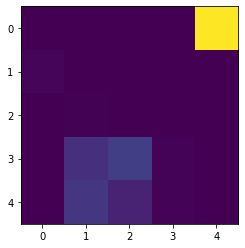

In [24]:
plt.imshow(tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

## Overlapping test

In [30]:
img2.shape

torch.Size([1, 1, 68, 68])

In [36]:
img2_shifted = torch.zeros_like(img2)
img2_shifted[:, :, :-2, :-2] += img2[:, :, 2:, 2:]
img2_shifted[:, :, -2:, -2:] = bg2[:, :, -2:, -2:]

bg2_shifted = torch.zeros_like(bg2)
bg2_shifted[:, :, :-2, :-2] += bg2[:, :, 2:, 2:]
bg2_shifted[:, :, -2:, -2:] = bg2[:, :, -2:, -2:]

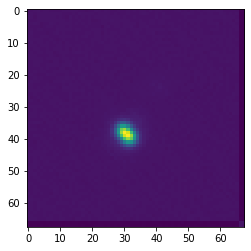

In [38]:
plt.imshow(img2_shifted[0, 0] + img2[0, 0])

In [48]:
img_recon2_shifted, tile_map_recon2_shifted = reconstruct_scene_at_coordinates(encoder, decoder, img2_shifted, bg2_shifted, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 68.24it/s]


In [49]:
tile_map_recon2_shifted["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[1.1550e-03, 1.3506e-03, 8.7460e-03, 1.0150e-02, 1.9117e-02],
        [2.1384e-03, 9.2484e-04, 1.9366e-03, 1.0549e-03, 9.5531e-04],
        [1.8606e-03, 5.2126e-03, 7.8585e-03, 1.6731e-03, 8.1036e-04],
        [1.5466e-03, 9.9966e-01, 1.8327e-04, 4.0884e-03, 2.4225e-04],
        [8.3108e-04, 1.2441e-04, 3.4786e-03, 4.1275e-04, 9.8425e-05]],
       device='cuda:0')

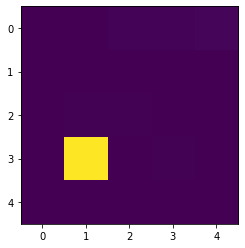

In [50]:
plt.imshow(tile_map_recon2_shifted["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

Okay, so how does our MCMC algorithm work?
1. Start with all tiles at zero
1. Sample original first
1. Sample overlap given original
1. Sample original given overlap
1. etc

In [51]:
log_probs = torch.stack((
    tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0],
    tile_map_recon2_shifted["n_source_log_probs"][0, :, :, 0, 0],
), dim = -1)

In [52]:
log_probs.shape

torch.Size([5, 5, 2])

In [140]:
def has_neighbor(idx, tiles):
    other = 1 - idx
    if idx == 0: #original; overlap is to the bottom and right
        neighbors_0 = (1 - tiles[:, :, other]) # has neighbor to bottom-right
        neighbors_0[1:, :]  &= (1 - tiles[:-1, :, other]) # has neighbor to top-right
        neighbors_0[:, 1:]  &= (1 - tiles[:, :-1, other]) # has neighbor to bottom-left
        neighbors_0[1:, 1:] &= (1 - tiles[:-1, :-1, other]) # has beighbor to top-left
    if idx == 1: #overlap; original is to the top and left
        neighbors_0 = (1 - tiles[:, :, other]) # has neighbor to top-left
        neighbors_0[:-1, :]  &= (1 - tiles[1:, :, other]) # has neighbor to bottom-right
        neighbors_0[:, :-1]  &= (1 - tiles[:, 1:, other]) # has neighbor to top-right
        neighbors_0[:-1, :-1] &= (1 - tiles[1:, 1:, other]) # has beighbor to bottom-right
    return neighbors_0

In [178]:
def sample_tile_marginals(log_probs, n_samples=1000):
    tiles = torch.zeros_like(log_probs, dtype=int)
    sum_tiles = torch.zeros_like(log_probs)
    for _ in range(n_samples):
        for idx in (0, 1):
            neighbors_0 = has_neighbor(idx, tiles)
            #print(neighbors_0)
            tiles[:, :, idx] = (torch.rand_like(tiles[:, :, 0], dtype=float).log() < log_probs[:, :, idx]) * neighbors_0
            #print(tiles[:, :, idx])
        sum_tiles += tiles
    return sum_tiles / n_samples

In [179]:
x = sample_tile_marginals(log_probs)

In [181]:
x[:, :, 0]

tensor([[0.0000, 0.0000, 0.0000, 0.0060, 0.9570],
        [0.0290, 0.0030, 0.0000, 0.0000, 0.0000],
        [0.0050, 0.0050, 0.0050, 0.0020, 0.0000],
        [0.0010, 0.0000, 0.0000, 0.0070, 0.0010],
        [0.0000, 0.0000, 0.0000, 0.0070, 0.0000]], device='cuda:0')

In [182]:
x[:, :, 1]

tensor([[0.0010, 0.0010, 0.0100, 0.0000, 0.0010],
        [0.0040, 0.0010, 0.0010, 0.0000, 0.0000],
        [0.0030, 0.0050, 0.0100, 0.0010, 0.0010],
        [0.0030, 1.0000, 0.0010, 0.0040, 0.0010],
        [0.0000, 0.0000, 0.0040, 0.0000, 0.0000]], device='cuda:0')

In [183]:
x.sum()

tensor(2.0800, device='cuda:0')

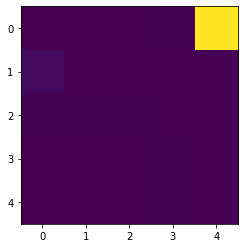

In [184]:
plt.imshow(x[:,:, 0].cpu())

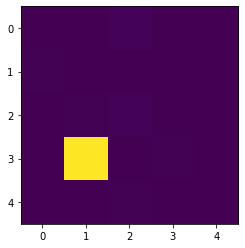

In [185]:
plt.imshow(x[:,:,1].cpu())